In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from ipywidgets import interact, IntSlider
from collections import Counter

In [2]:
PROJECT_DIR = Path(r"C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons")
LABELS_PATH = 'C:/Users/abram/PycharmProjects/DrivenData_DAT_Parkinsons/data/niftis/train_labels_JNDlMjr.csv'
labels = pd.read_csv(LABELS_PATH)
print(labels.head())
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
files_uid = {f.stem.replace(".nii", "") for f in NIFTI_DIR.glob("*.nii.gz")}
labels_uid = set(labels["uid"])
files = sorted(NIFTI_DIR.glob("*.nii.gz"))

        uid  is_pathologic
0  xaji0y6d            0.0
1  pbhsahxt            0.0
2  hv3a3zmf            0.0
3  8mdd4v30            0.0
4  t9nt3w5u            1.0


In [3]:
target_map = labels.set_index("uid")["is_pathologic"].to_dict()

10 [[   2.46000004    0.           -0.         -316.48001099]
 [   0.            2.46000004   -0.         -324.83999634]
 [   0.            0.            2.46000004 -657.08001709]
 [   0.            0.            0.            1.        ]]
('R', 'A', 'S')
UID: 08liuqdn


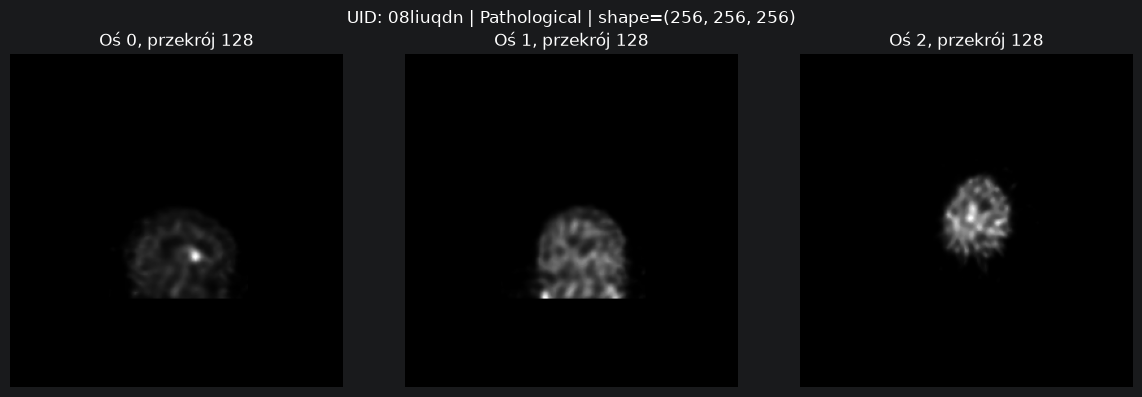

11 [[ 3.86129475e+00 -4.40568864e-01 -2.65282005e-01 -1.65172577e+02]
 [ 4.40148026e-01  3.87036514e+00 -2.12396830e-02 -1.60238159e+02]
 [ 2.65665561e-01 -8.91042687e-03  3.89090919e+00 -1.35164986e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
('R', 'A', 'S')
UID: 08uhbxlb


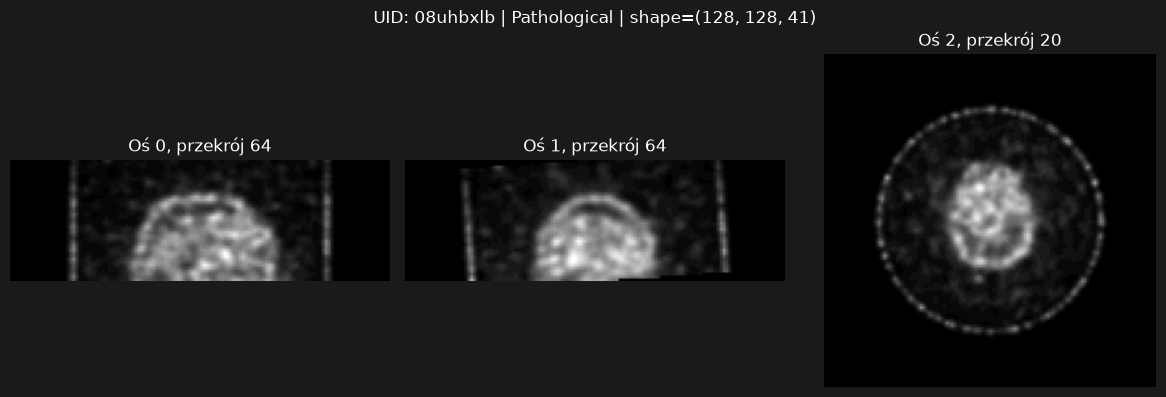

12 [[ 3.88161469e+00  1.87760025e-01 -2.68124402e-01 -2.86445557e+02]
 [-1.70624390e-01  3.88360786e+00  2.50060648e-01 -2.92113132e+01]
 [ 2.79036254e-01 -2.37151384e-01  3.88272834e+00  3.10310402e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
('R', 'A', 'S')
UID: 09lzrk79


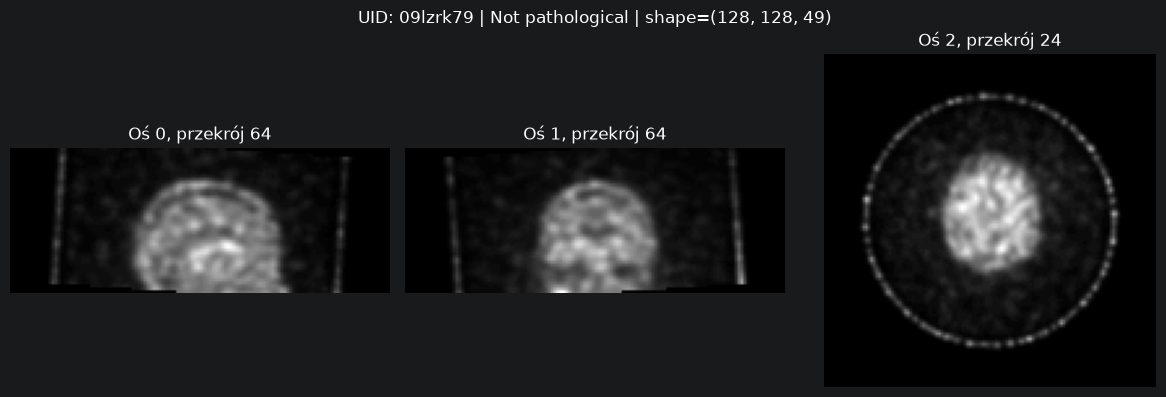

13 [[   2.46000004    0.           -0.         -315.42999268]
 [   0.            2.46000004   -0.         -306.70001221]
 [   0.            0.            2.46000004 -617.48999023]
 [   0.            0.            0.            1.        ]]
('R', 'A', 'S')
UID: 09vs9kkh


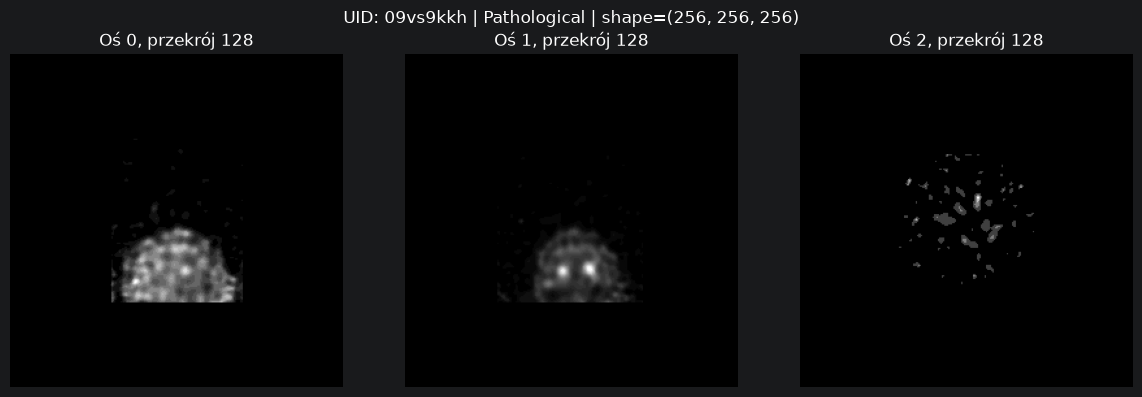

14 [[   2.46000004    0.           -0.         -314.01998901]
 [   0.            2.46000004   -0.         -324.83999634]
 [   0.            0.            2.46000004 -648.67999268]
 [   0.            0.            0.            1.        ]]
('R', 'A', 'S')
UID: 0aeoorbt


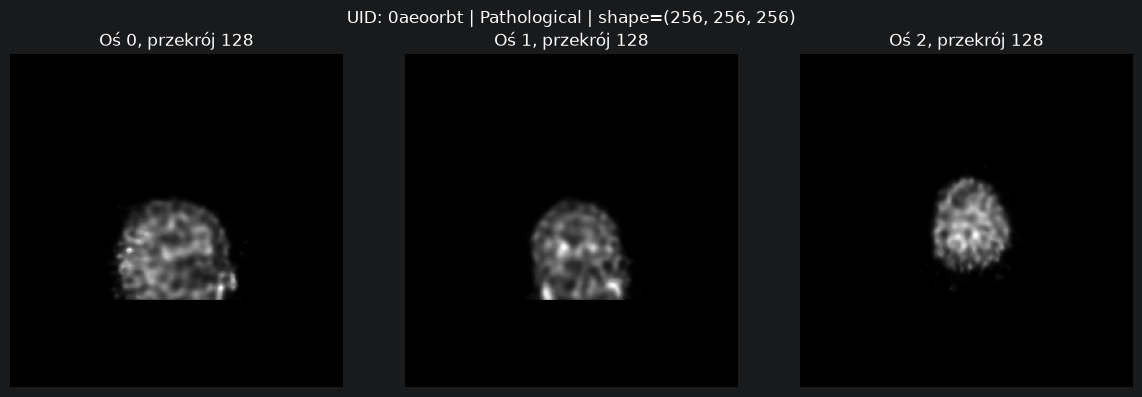

15 [[   2.46000004    0.           -0.         -317.89001465]
 [   0.            2.46000004   -0.         -306.70001221]
 [   0.            0.            2.46000004 -674.98999023]
 [   0.            0.            0.            1.        ]]
('R', 'A', 'S')
UID: 0bq1s9ry


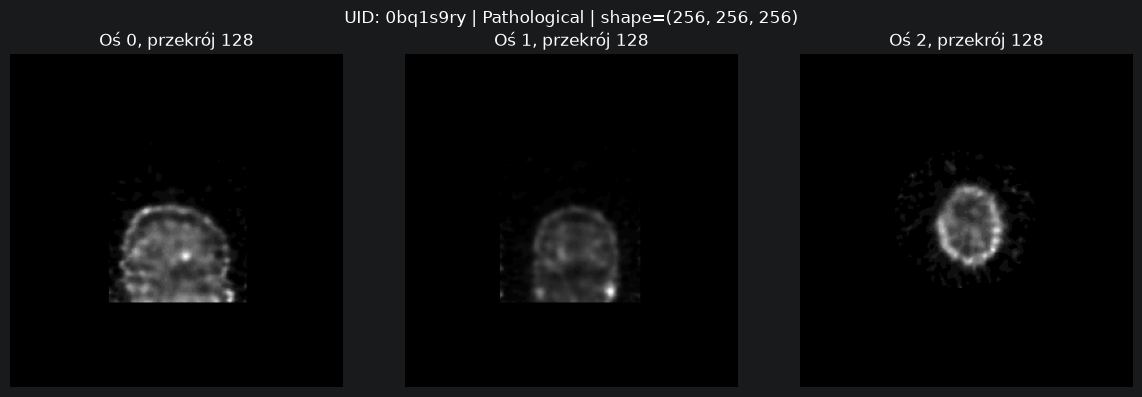

16 [[ 3.89534473e+00 -1.26716467e-02  5.94511721e-03 -2.44124084e+02]
 [ 1.27122980e-02  3.89525676e+00 -2.68229246e-02 -8.73423615e+01]
 [-5.85768931e-03  2.68421527e-02  3.89527273e+00 -5.72551193e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
('R', 'A', 'S')
UID: 0dk0get8


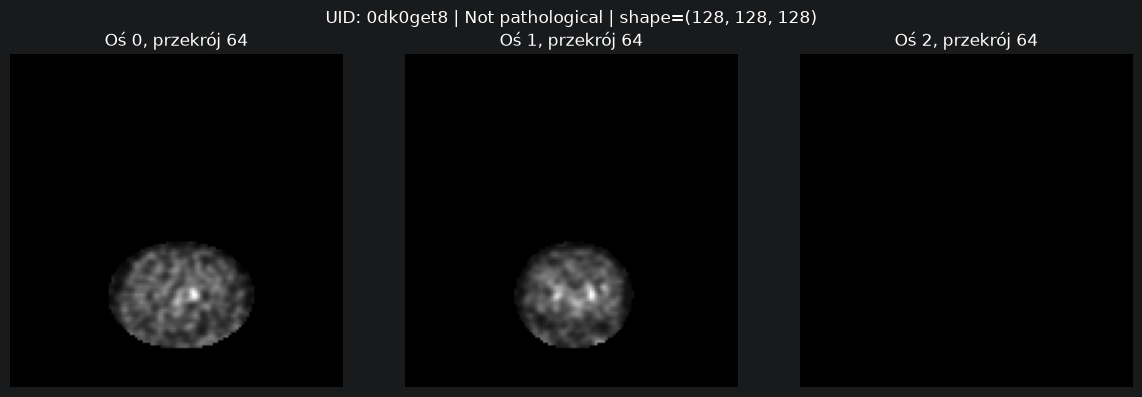

17 [[  2.29999995   0.          -0.         -11.54709435]
 [  0.           2.29999995  -0.         -11.54709435]
 [  0.           0.           2.29999995 316.68978882]
 [  0.           0.           0.           1.        ]]
('R', 'A', 'S')
UID: 0dl5e11e


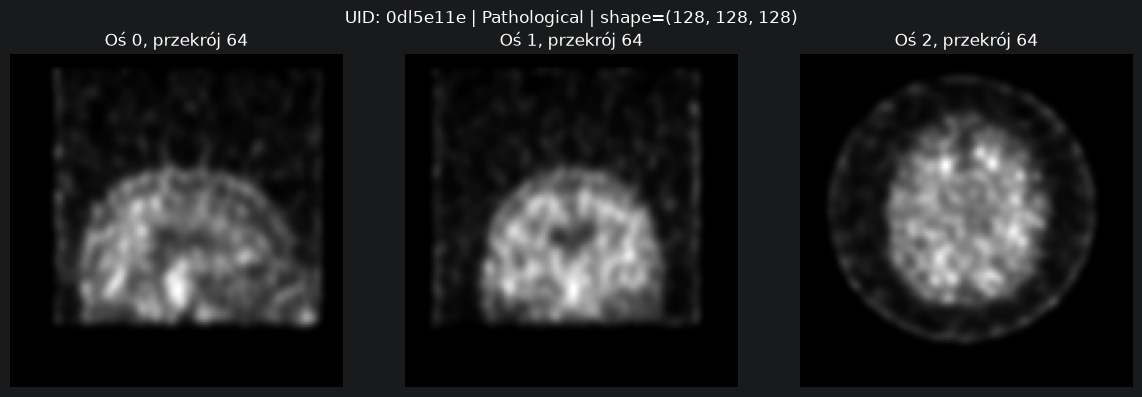

18 [[  2.29999995   0.          -0.         -11.54709435]
 [  0.           2.29999995  -0.         -11.54709435]
 [  0.           0.           2.29999995 304.18978882]
 [  0.           0.           0.           1.        ]]
('R', 'A', 'S')
UID: 0ezzf8s2


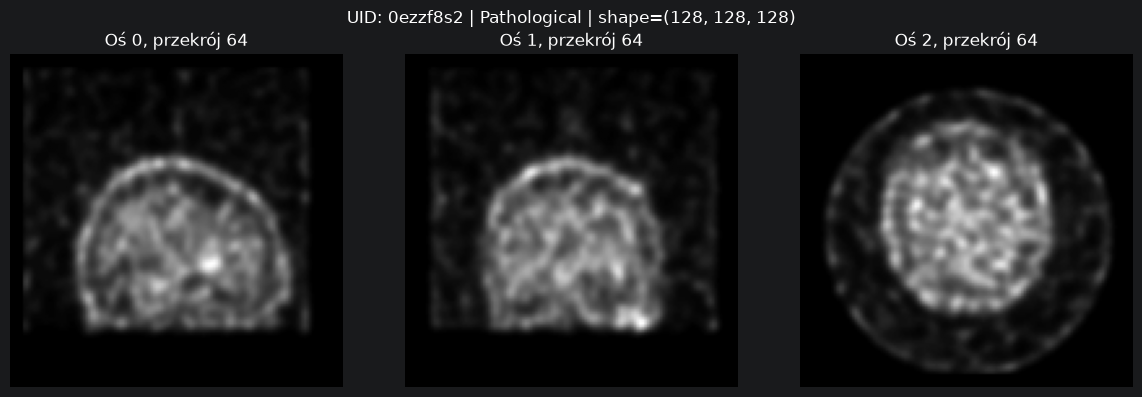

19 [[ 3.89011455e+00 -3.42407264e-02 -1.99590117e-01 -2.43183197e+02]
 [ 3.31677236e-02  3.89516783e+00 -2.18320675e-02 -6.84206085e+01]
 [ 1.99534476e-01  2.00793073e-02  3.89482832e+00  4.58900757e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
('R', 'A', 'S')
UID: 0fgzvrct


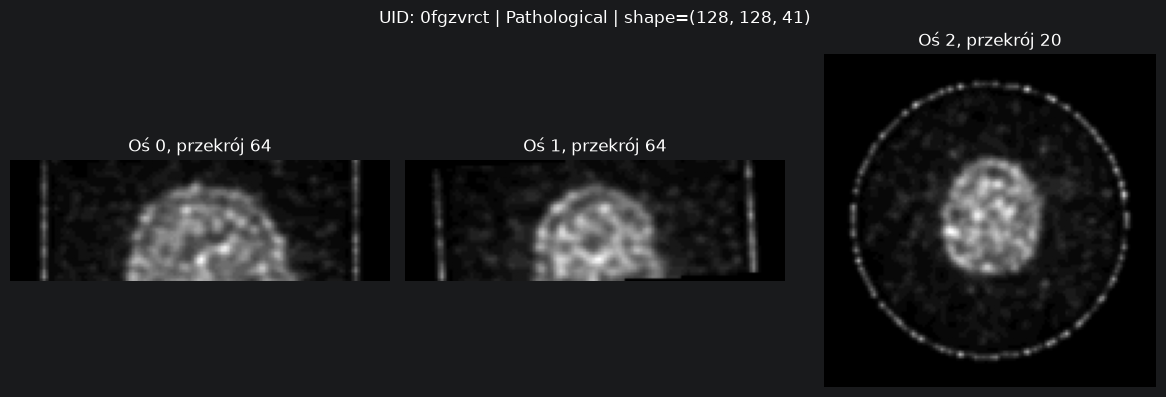

In [4]:
target_map = labels.set_index("uid")["is_pathologic"].to_dict()

for i in range(10):
    file = files[i+10]

    uid = file.stem.replace(".nii", "")
    target = target_map[uid]

    diagnosis = "Pathological" if target == 1 else "Not pathological"

    volume = nib.load(file).get_fdata()
    import nibabel as nib

    img = nib.load(file)
    print(f'{i+10} {img.affine}')
    print(nib.aff2axcodes(img.affine))

    x = volume.shape[0] // 2
    y = volume.shape[1] // 2
    z = volume.shape[2] // 2

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].imshow(volume[x, :, :].T, cmap="gray", origin="lower")
    ax[1].imshow(volume[:, y, :].T, cmap="gray", origin="lower")
    ax[2].imshow(volume[:, :, z].T, cmap="gray", origin="lower")

    ax[0].set_title(f"Oś 0, przekrój {x}")
    ax[1].set_title(f"Oś 1, przekrój {y}")
    ax[2].set_title(f"Oś 2, przekrój {z}")

    for a in ax:
        a.axis("off")

    fig.suptitle(
        f"UID: {uid} | {diagnosis} | shape={volume.shape}"
    )
    print(f"UID: {uid}")
    plt.tight_layout()
    plt.show()

In [5]:
orientations = []

for file in files:
    img = nib.load(file)
    orientation = nib.aff2axcodes(img.affine)
    orientations.append(orientation)

print(Counter(orientations))

Counter({('R', 'A', 'S'): 1362})


In [6]:
uid_to_show = "0fgzvrct"

file = next(
    f for f in files
    if f.name == f"{uid_to_show}.nii.gz"
)

volume = nib.load(file).get_fdata()

print("Plik:", file.name)
print("Shape:", volume.shape)
print("Min:", volume.min())
print("Max:", volume.max())

Plik: 0fgzvrct.nii.gz
Shape: (128, 128, 41)
Min: 0.0
Max: 64.0


In [7]:
@interact(
    z=IntSlider(
        min=0,
        max=volume.shape[2] - 1,
        step=1,
        value=volume.shape[2] // 2,
        continuous_update=False
    )
)
def show_slice(z):
    plt.figure(figsize=(7, 7))
    plt.imshow(
        volume[:, :, z].T,
        cmap="gray",
        origin="lower"
    )
    plt.title(f"UID: {uid_to_show} | Oś 2 | przekrój {z}")
    plt.axis("off")
    plt.show()

interactive(children=(IntSlider(value=20, continuous_update=False, description='z', max=40), Output()), _dom_c…

In [8]:
@interact(
    x=IntSlider(
        min=0,
        max=volume.shape[0] - 1,
        value=volume.shape[0] // 2,
        continuous_update=False
    ),
    y=IntSlider(
        min=0,
        max=volume.shape[1] - 1,
        value=volume.shape[1] // 2,
        continuous_update=False
    ),
    z=IntSlider(
        min=0,
        max=volume.shape[2] - 1,
        value=volume.shape[2] // 2,
        continuous_update=False
    )
)
def show_mri(x, y, z):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(volume[x, :, :].T, cmap="gray", origin="lower")
    ax[1].imshow(volume[:, y, :].T, cmap="gray", origin="lower")
    ax[2].imshow(volume[:, :, z].T, cmap="gray", origin="lower")

    ax[0].set_title(f"Oś 0, przekrój {x}")
    ax[1].set_title(f"Oś 1, przekrój {y}")
    ax[2].set_title(f"Oś 2, przekrój {z}")

    for a in ax:
        a.axis("off")

    fig.suptitle(
        f"UID: {uid_to_show} | shape={volume.shape}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=64, continuous_update=False, description='x', max=127), IntSlider(value=…